# 04 · Visualisation snippets

Collect helper functions and examples for visualising solutions and residuals.

In [ ]:
from helmholtz_basics import GridSpec, FiniteDifference, PointSource, gmres_solve
from helmholtz_basics.visualisation import plot_field, plot_residuals

%matplotlib inline

grid = GridSpec(dims=2, shape=(50, 50), lengths=(1.0, 1.0))
disc = FiniteDifference(wavenumber=25.0)
A = disc.build_operator(grid)
load = PointSource(location='centre')
b = load.build(grid)
result = gmres_solve(A, b, tol=1e-6, maxiter=200)

field = result.solution.reshape(grid.shape)
plot_field(grid, field, title='Field amplitude')
plot_residuals(result.residuals)

### Suggested follow-ups

- Swap `plot_field` for your own Matplotlib code if you need custom styling.
- Capture plots to disk inside a results directory for reproducible studies.
- Add widgets (e.g. ipywidgets) to build interactive dashboards.

In [1]:
# This script generates placeholder/template visuals and LaTeX tables
# for items 1–17 (up to Chapter 3) as discussed. Each figure is a single
# Matplotlib plot (no seaborn, no multi-axes grids), saved as vector PDF.
# Tables are saved as .tex files. Replace TODO sections with your data
# once available.

import os
import numpy as np
import matplotlib.pyplot as plt
from textwrap import dedent

BASE = "/mnt/data/fig"
TABBASE = "/mnt/data/tab"
os.makedirs(BASE, exist_ok=True)
os.makedirs(TABBASE, exist_ok=True)

# Utility: simple swimlane-style block diagram using rectangles and arrows
def draw_blocks(ax, blocks, spacing=1.8):
    ax.set_aspect('equal')
    ax.axis('off')
    x = 0.0
    y = 0.0
    rects = []
    for label in blocks:
        r = plt.Rectangle((x, y), 1.6, 0.8, fill=False, linewidth=1.5)
        ax.add_patch(r)
        ax.text(x+0.8, y+0.4, label, ha='center', va='center')
        rects.append((x, y))
        x += spacing
    # arrows
    for i in range(len(rects)-1):
        x0, y0 = rects[i]
        x1, y1 = rects[i+1]
        ax.annotate("",
                    xy=(x1-0.1, y1+0.4), xytext=(x0+1.6, y0+0.4),
                    arrowprops=dict(arrowstyle="->", lw=1.5))
    # autoscale the view
    ax.set_xlim(-0.5, rects[-1][0] + 2.3)
    ax.set_ylim(-0.5, 1.5)

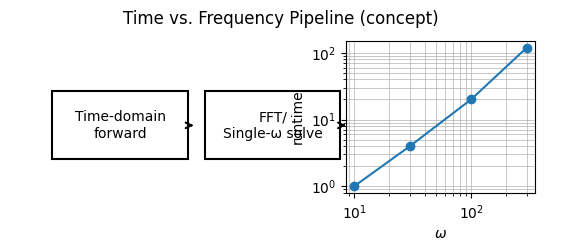

In [2]:
# 1) Time vs. Frequency Pipeline (cost growth)
def fig1_pipeline_time_vs_freq():
    fig, ax = plt.subplots(figsize=(8, 2.2))
    draw_blocks(ax, ["Time-domain\nforward", "FFT/\nSingle-ω solve", "Analysis/\nInversion"])
    ax.set_title("Time vs. Frequency Pipeline (concept)")

    # Inset line chart (runtime vs ω) — simple placeholder using axes inset
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    inset = inset_axes(ax, width="35%", height="90%", loc='center right', borderpad=1.2)
    inset.set_xscale('log')
    inset.set_yscale('log')
    w = np.array([10, 30, 100, 300])
    t = np.array([1.0, 4.0, 20.0, 120.0])  # placeholder runtimes
    inset.plot(w, t, marker='o')
    inset.set_xlabel(r'$\omega$')
    inset.set_ylabel('runtime')
    inset.grid(True, which='both', linewidth=0.5)
    fig.savefig(f"{BASE}/pipeline_time_vs_freq.pdf", bbox_inches='tight')
fig1_pipeline_time_vs_freq()

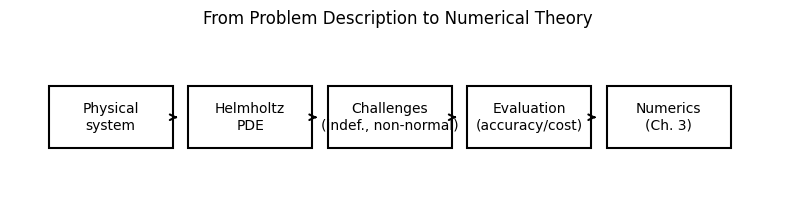

In [3]:
# 2) Physics → PDE → Challenges → Evaluation → Numerics handoff
def fig2_pipeline_problem_to_numerics():
    fig, ax = plt.subplots(figsize=(10, 2.2))
    draw_blocks(ax, ["Physical\nsystem", "Helmholtz\nPDE", "Challenges\n(indef., non-normal)", "Evaluation\n(accuracy/cost)", "Numerics\n(Ch. 3)"])
    ax.set_title("From Problem Description to Numerical Theory")
    fig.savefig(f"{BASE}/pipeline_problem_to_numerics.pdf", bbox_inches='tight')
fig2_pipeline_problem_to_numerics()

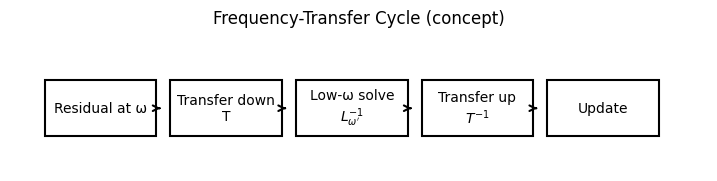

In [4]:
# 3) Frequency-transfer loop (concept)
def fig3_freq_transfer_loop():
    fig, ax = plt.subplots(figsize=(9, 2.4))
    draw_blocks(ax, ["Residual at ω", "Transfer down\nT", "Low-ω solve\n$L_{ω'}^{-1}$", "Transfer up\n$T^{-1}$", "Update"])
    ax.set_title("Frequency-Transfer Cycle (concept)")
    fig.savefig(f"{BASE}/freq_transfer_loop_concept.pdf", bbox_inches='tight')
fig3_freq_transfer_loop()

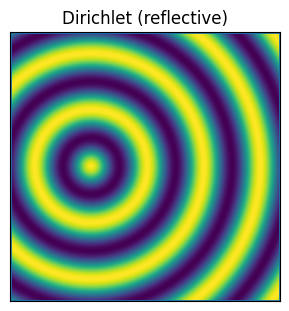

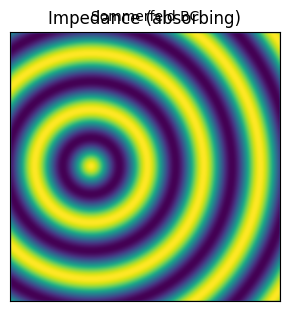

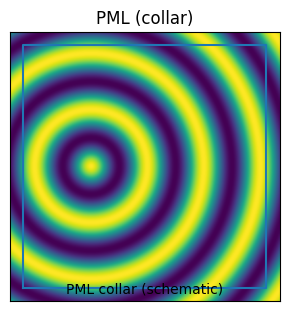

In [5]:
# 4) Boundary modeling gallery (schematic)
def fig4_boundary_gallery():
    # Create a simple 1x3 schematic with wavefront arcs near a boundary
    x = np.linspace(0, 1.0, 400)
    y = np.linspace(0, 1.0, 400)
    X, Y = np.meshgrid(x, y)
    k = 30.0  # placeholder
    # simple circular wavefronts centered at (0.3,0.5)
    R = np.sqrt((X-0.3)**2 + (Y-0.5)**2)
    U = np.cos(k*R)

    titles = ["Dirichlet (reflective)", "Impedance (absorbing)", "PML (collar)"]
    for i, ttl in enumerate(titles):
        fig, ax = plt.subplots(figsize=(3.5, 3.5))
        im = ax.imshow(U, origin='lower', extent=[0,1,0,1])
        ax.set_title(ttl)
        ax.set_xticks([]); ax.set_yticks([])
        # Draw boundary cues
        if i == 0:
            ax.plot([0,1,1,0,0],[0,0,1,1,0], lw=2)
        elif i == 1:
            ax.plot([0,1,1,0,0],[0,0,1,1,0], lw=1)
            ax.text(0.5, 1.03, "Sommerfeld BC", ha='center', va='bottom')
        else:
            # PML collar rectangle
            ax.plot([0.05,0.95,0.95,0.05,0.05],[0.05,0.05,0.95,0.95,0.05], lw=1.5)
            ax.text(0.5, 0.02, "PML collar (schematic)", ha='center', va='bottom')
        fig.savefig(f"{BASE}/boundaries_gallery_{i+1}.pdf", bbox_inches='tight')
fig4_boundary_gallery()

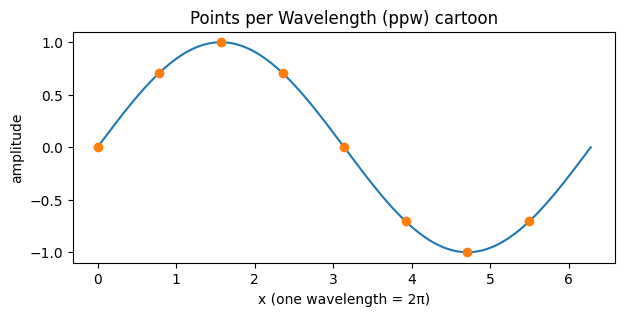

In [6]:
# 5) PPW rules (cartoon + scaling)
def fig5_ppw_rules():
    fig, ax = plt.subplots(figsize=(7, 3))
    # Sampling cartoon: one period across 8 and 4 samples
    x = np.linspace(0, 2*np.pi, 400)
    y = np.sin(x)
    ax.plot(x, y)
    # overlay sample points
    samples = 8
    xs = np.linspace(0, 2*np.pi, samples, endpoint=False)
    ax.plot(xs, np.sin(xs), marker='o', linestyle='')
    ax.set_title("Points per Wavelength (ppw) cartoon")
    ax.set_xlabel("x (one wavelength = 2π)")
    ax.set_ylabel("amplitude")
    fig.savefig(f"{BASE}/ppw_rules.pdf", bbox_inches='tight')
fig5_ppw_rules()

In [7]:
# 6) Problem ladder table
def tab6_problem_ladder():
    tex = dedent(r"""
    \begin{table}[t]
    \centering
    \caption{Problem ladder and qualitative focus.}
    \label{tab:problem-ladder}
    \begin{tabular}{l l l}
    \hline
    Case & Main difficulty & Evaluation focus \\
    \hline
    2D homogeneous & Boundary absorption & Accuracy, reflections \\
    2D heterogeneous & Non-normality, variable $\lambda$ & Robustness \\
    3D homogeneous & Scaling with dimension & Runtime, memory \\
    3D heterogeneous & Full complexity & All metrics \\
    \hline
    \end{tabular}
    \end{table}
    """).strip()
    with open(f"{TABBASE}/problem_ladder.tex", "w") as f:
        f.write(tex)
tab6_problem_ladder()

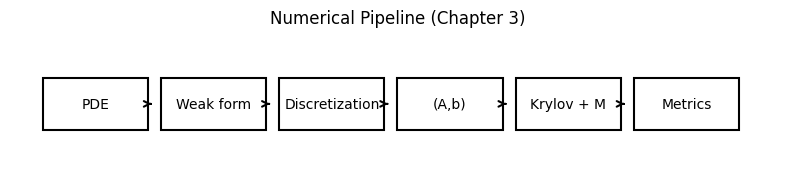

In [8]:
# 7) Numerics pipeline
def fig7_pipeline_numerics():
    fig, ax = plt.subplots(figsize=(10, 2.2))
    draw_blocks(ax, ["PDE", "Weak form", "Discretization", "(A,b)", "Krylov + M", "Metrics"])
    ax.set_title("Numerical Pipeline (Chapter 3)")
    fig.savefig(f"{BASE}/pipeline_numerics.pdf", bbox_inches='tight')
fig7_pipeline_numerics()

In [9]:
# 8) FD stencils table
def tab8_fd_stencils():
    tex = dedent(r"""
    \begin{table}[t]
    \centering
    \caption{Finite-difference Laplacian stencils and orders (placeholders).}
    \label{tab:fd-stencils}
    \begin{tabular}{l l l}
    \hline
    Stencil & Formula & Order \\
    \hline
    1D 3-pt & $(-u_{i-1}+2u_i-u_{i+1})/h^2$ & 2 \\
    1D 5-pt & $(u_{i-2}-16u_{i-1}+30u_i-16u_{i+1}+u_{i+2})/(12h^2)$ & 4 \\
    2D 5-pt & standard cross & 2 \\
    2D 9-pt & compact & 4 \\
    \hline
    \end{tabular}
    \end{table}
    """).strip()
    with open(f"{TABBASE}/fd_stencils.tex", "w") as f:
        f.write(tex)
tab8_fd_stencils()


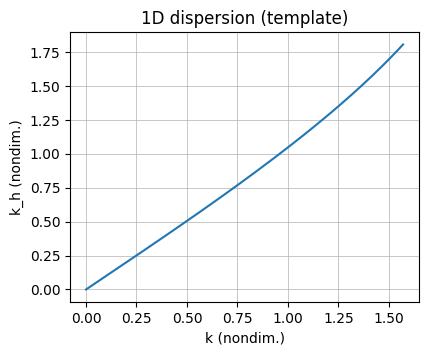

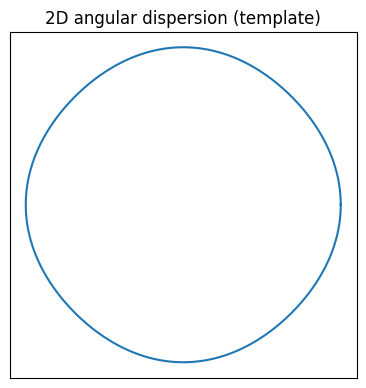

In [10]:
# 9) Dispersion curves (1D and 2D polar anisotropy placeholder)
def fig9_dispersion_fd():
    # 1D k_h vs k
    fig, ax = plt.subplots(figsize=(4.5, 3.5))
    k = np.linspace(0.0, np.pi/2, 200)  # nondimensional kh in [0, pi/2]
    kh = 2*np.arcsin(np.minimum(1.0, np.sqrt(k**2 * (0.25))))  # placeholder, not physical; replace with exact relation
    ax.plot(k, kh)
    ax.set_xlabel("k (nondim.)")
    ax.set_ylabel("k_h (nondim.)")
    ax.set_title("1D dispersion (template)")
    ax.grid(True, which='both', linewidth=0.5)
    fig.savefig(f"{BASE}/dispersion_fd_1d.pdf", bbox_inches='tight')

    # 2D angular dispersion (placeholder polar plot mapped to Cartesian)
    theta = np.linspace(0, 2*np.pi, 361)
    # placeholder anisotropy: error depends on angle
    err = 0.05*(1 + 0.3*np.cos(4*theta))
    r = 1 + err
    x = r*np.cos(theta)
    y = r*np.sin(theta)
    fig2, ax2 = plt.subplots(figsize=(4.5, 4.5))
    ax2.plot(x, y)
    ax2.set_aspect('equal', 'box')
    ax2.set_title("2D angular dispersion (template)")
    ax2.set_xticks([]); ax2.set_yticks([])
    fig2.savefig(f"{BASE}/dispersion_fd_2d_polar.pdf", bbox_inches='tight')
fig9_dispersion_fd()

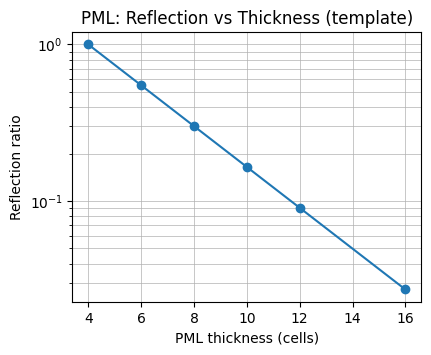

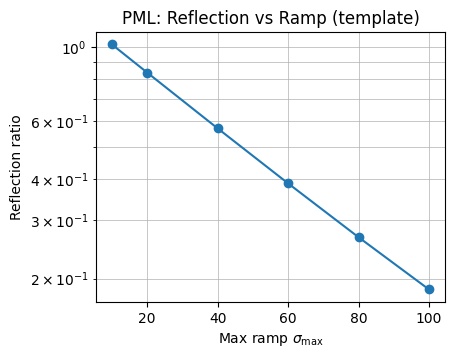

In [11]:
# 10) PML parameter sweep (reflection vs thickness / ramp) — placeholder synthetic curves
def fig10_pml_reflection_sweep():
    thickness = np.array([4, 6, 8, 10, 12, 16])
    refl_thick = np.exp(-0.3*(thickness-4))  # synthetic

    sigmax = np.array([10, 20, 40, 60, 80, 100])
    refl_sigma = np.exp(-0.02*(sigmax-10)) + 0.02  # synthetic

    # Thickness figure
    fig, ax = plt.subplots(figsize=(4.5, 3.5))
    ax.semilogy(thickness, refl_thick, marker='o')
    ax.set_xlabel("PML thickness (cells)")
    ax.set_ylabel("Reflection ratio")
    ax.set_title("PML: Reflection vs Thickness (template)")
    ax.grid(True, which='both', linewidth=0.5)
    fig.savefig(f"{BASE}/pml_reflection_vs_thickness.pdf", bbox_inches='tight')

    # Sigma figure
    fig2, ax2 = plt.subplots(figsize=(4.5, 3.5))
    ax2.semilogy(sigmax, refl_sigma, marker='o')
    ax2.set_xlabel(r"Max ramp $\sigma_{\max}$")
    ax2.set_ylabel("Reflection ratio")
    ax2.set_title("PML: Reflection vs Ramp (template)")
    ax2.grid(True, which='both', linewidth=0.5)
    fig2.savefig(f"{BASE}/pml_reflection_vs_sigma.pdf", bbox_inches='tight')
fig10_pml_reflection_sweep()

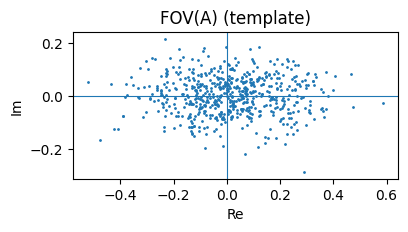

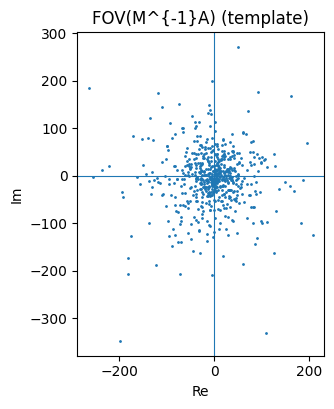

In [12]:
# 11) FOV and spectrum before/after preconditioning (toy matrices)
def fig11_fov_before_after():
    rng = np.random.default_rng(0)
    n = 60
    # Non-normal toy A
    Q, _ = np.linalg.qr(rng.normal(size=(n, n)))
    D = np.diag(np.linspace(-2, 2, n))
    A = Q @ D @ np.linalg.inv(Q) + 0.1*rng.normal(size=(n, n))
    # Preconditioned version: shift/scale
    M_inv_A = np.linalg.inv(np.eye(n) + 0.5*np.triu(rng.normal(size=(n, n)))) @ A

    def fov_samples(M, m=1000):
        v = rng.normal(size=(M.shape[0], m)) + 1j*rng.normal(size=(M.shape[0], m))
        v = v / np.linalg.norm(v, axis=0, keepdims=True)
        vals = np.sum(np.conj(v) * (M @ v), axis=0) / np.sum(np.conj(v) * v, axis=0)
        return vals

    fov_A = fov_samples(A, 600)
    fov_MA = fov_samples(M_inv_A, 600)

    # Plot A
    fig, ax = plt.subplots(figsize=(4.2, 4.2))
    ax.plot(np.real(fov_A), np.imag(fov_A), '.', ms=2)
    ax.axvline(0, linewidth=0.8); ax.axhline(0, linewidth=0.8)
    ax.set_title("FOV(A) (template)")
    ax.set_xlabel("Re"); ax.set_ylabel("Im")
    ax.set_aspect('equal', 'box')
    fig.savefig(f"{BASE}/fov_A.pdf", bbox_inches='tight')

    # Plot M^{-1}A
    fig2, ax2 = plt.subplots(figsize=(4.2, 4.2))
    ax2.plot(np.real(fov_MA), np.imag(fov_MA), '.', ms=2)
    ax2.axvline(0, linewidth=0.8); ax2.axhline(0, linewidth=0.8)
    ax2.set_title("FOV(M^{-1}A) (template)")
    ax2.set_xlabel("Re"); ax2.set_ylabel("Im")
    ax2.set_aspect('equal', 'box')
    fig2.savefig(f"{BASE}/fov_MinvA.pdf", bbox_inches='tight')
fig11_fov_before_after()


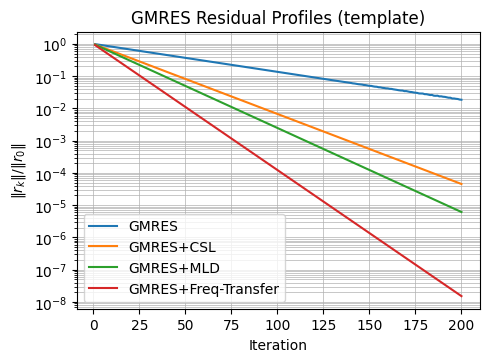

In [13]:
# 12) GMRES residual profiles (synthetic)
def fig12_gmres_profiles():
    it = np.arange(1, 201)
    base = np.exp(-0.02*it) + 1e-3*np.random.default_rng(1).random(len(it))
    csl = np.exp(-0.05*it)
    mld = np.exp(-0.06*it)
    ftp = np.exp(-0.09*it)

    fig, ax = plt.subplots(figsize=(5.2, 3.6))
    ax.semilogy(it, base, label="GMRES")
    ax.semilogy(it, csl, label="GMRES+CSL")
    ax.semilogy(it, mld, label="GMRES+MLD")
    ax.semilogy(it, ftp, label="GMRES+Freq-Transfer")
    ax.set_xlabel("Iteration")
    ax.set_ylabel(r"$\|r_k\|/\|r_0\|$")
    ax.set_title("GMRES Residual Profiles (template)")
    ax.legend()
    ax.grid(True, which='both', linewidth=0.5)
    fig.savefig(f"{BASE}/gmres_profiles.pdf", bbox_inches='tight')
fig12_gmres_profiles()

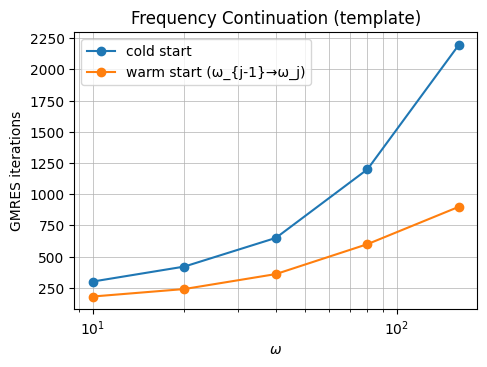

In [14]:
# 13) Frequency continuation warm-starts (synthetic)
def fig13_freq_continuation():
    w = np.array([10, 20, 40, 80, 160])
    it_cold = np.array([300, 420, 650, 1200, 2200])
    it_warm = np.array([180, 240, 360, 600, 900])

    fig, ax = plt.subplots(figsize=(5.2, 3.6))
    ax.plot(w, it_cold, marker='o', label="cold start")
    ax.plot(w, it_warm, marker='o', label="warm start (ω_{j-1}→ω_j)")
    ax.set_xscale('log')
    ax.set_xlabel(r'$\omega$')
    ax.set_ylabel("GMRES iterations")
    ax.set_title("Frequency Continuation (template)")
    ax.legend()
    ax.grid(True, which='both', linewidth=0.5)
    fig.savefig(f"{BASE}/frequency_continuation.pdf", bbox_inches='tight')
fig13_freq_continuation()

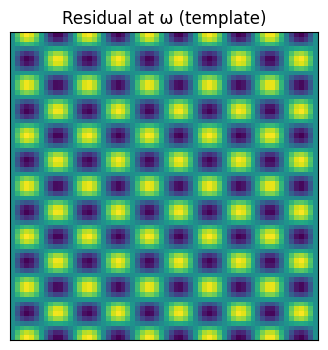

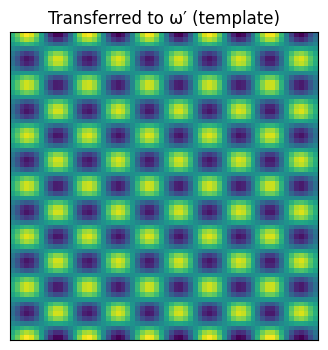

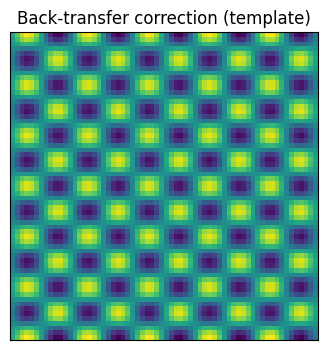

In [15]:
# 14) Frequency-transfer quality demo (toy)
def fig14_freq_transfer_quality():
    # Create a synthetic residual field and show two "transfers"
    n = 64
    x = np.linspace(0, 1, n)
    X, Y = np.meshgrid(x, x)
    r_omega = np.sin(10*np.pi*X) * np.cos(12*np.pi*Y)
    # "Transfer down" as simple Gaussian blur + rescale (placeholder)
    from scipy.ndimage import gaussian_filter
    r_low = gaussian_filter(r_omega, sigma=1.2)
    # "Back-transfer" as sharpening (placeholder)
    r_back = r_low + (r_low - gaussian_filter(r_low, sigma=1.0))

    # Single plot per figure (three separate PDFs)
    for data, name, title in [(r_omega, "r_omega", "Residual at ω (template)"),
                              (r_low, "T_r_omega", "Transferred to ω′ (template)"),
                              (r_back, "Tinv_correction", "Back-transfer correction (template)")]:
        fig, ax = plt.subplots(figsize=(4.0, 4.0))
        im = ax.imshow(data, origin='lower')
        ax.set_title(title)
        ax.set_xticks([]); ax.set_yticks([])
        fig.savefig(f"{BASE}/freq_transfer_{name}.pdf", bbox_inches='tight')
fig14_freq_transfer_quality()

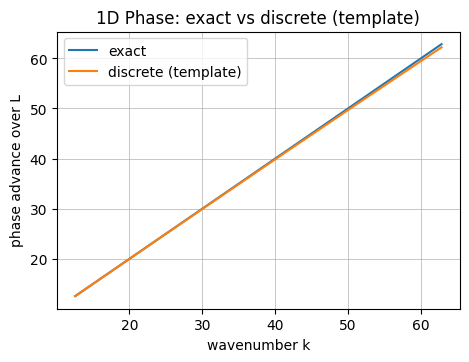

In [16]:
# 15) 1D appendix plots (closed-form vs discrete) — template
def fig15_1d_dispersion():
    # Exact vs discrete phase after length L
    L = 1.0
    k = np.linspace(2*np.pi*2, 2*np.pi*10, 100)  # 2–10 wavelengths across unit length
    # exact phase advance
    phi_exact = k*L
    # discrete: placeholder with mild bias
    phi_disc = k*L*(1 - 0.01*(k/np.max(k))**2)

    fig, ax = plt.subplots(figsize=(5.2, 3.6))
    ax.plot(k, phi_exact, label="exact")
    ax.plot(k, phi_disc, label="discrete (template)")
    ax.set_xlabel("wavenumber k")
    ax.set_ylabel("phase advance over L")
    ax.set_title("1D Phase: exact vs discrete (template)")
    ax.legend()
    ax.grid(True, which='both', linewidth=0.5)
    fig.savefig(f"{BASE}/1d_plane_wave_dispersion.pdf", bbox_inches='tight')
fig15_1d_dispersion()

In [21]:
# 16) Cost model table (predictive) — template
from textwrap import dedent
import os

TABBASE = "tab"  # adjust to your path
os.makedirs(TABBASE, exist_ok=True)

def tab16_cost_model_ascii():
    rows = [
        (r"$64\times 64$",  r"$\omega=40$",  "4.1e3", "0.3 ms", "1.2 ms", "80 it",  "0.12 s"),
        (r"$128\times 128$",r"$\omega=80$",  "1.6e4", "0.9 ms", "2.8 ms", "140 it", "0.52 s"),
        (r"$256\times 256$",r"$\omega=160$", "6.6e4", "3.4 ms", "8.0 ms", "220 it", "2.5 s"),
    ]
    tex = dedent(r"""
    \begin{table}[t]
    \centering
    \caption{Predictive cost model (template).}
    \label{tab:cost-model}
    \begin{tabular}{l l r r r r r}
    \hline
    Grid & $\omega$ & DoFs $N$ & $c_{\mathrm{mv}}$ & $c_{\mathrm{prec}}$ & $n_{\mathrm{it}}$ & Pred.\ time \\
    \hline
    """).lstrip()
    for r in rows:
        tex += " {} & {} & {} & {} & {} & {} & {} \\\\\n".format(*r)
    tex += dedent(r"""
    \hline
    \end{tabular}
    \end{table}
    """)
    with open(os.path.join(TABBASE, "cost_model.tex"), "w", encoding="utf-8") as f:
        f.write(tex)

tab16_cost_model_ascii()

In [19]:
# 17) Implementation parameters sheet
def tab17_impl_params():
    tex = dedent(r"""
    \begin{table}[t]
    \centering
    \caption{Implementation parameters (to be filled with experiment settings).}
    \label{tab:impl-params}
    \begin{tabular}{l l}
    \hline
    Parameter & Value/Rule \\
    \hline
    Points per wavelength (ppw) & 8--12 \\
    Stencil order (FD) & 2 / 4 \\
    PML thickness & (e.g.) 8--16 cells \\
    PML $\sigma$-ramp & (e.g.) quadratic \\
    CSL shift $\beta(kh)$ & (e.g.) 0.5--0.8 \\
    Deflation space size $r$ & (e.g.) 50--200 \\
    $T_h$ stencil radius & (e.g.) 1--2 cells \\
    GMRES($m$), tol & (e.g.) $m=30$, $10^{-6}$ \\
    Hardware & (e.g.) CPU model, RAM \\
    \hline
    \end{tabular}
    \end{table}
    """).strip()
    with open(f"{TABBASE}/impl_params.tex", "w") as f:
        f.write(tex)
tab17_impl_params()
